# 🧠 ANN Project: Diabetes Prediction
### Using Artificial Neural Network (Deep Learning)

**Dataset:** Pima Indians Diabetes Dataset  
**Type:** Binary Classification (Diabetes: Yes / No)  
**Level:** Beginner-Friendly | Learning Purpose

---
> **Goal:** Predict whether a patient has diabetes based on medical measurements like Glucose, BMI, Age, etc.


##  What is ANN?

An **Artificial Neural Network (ANN)** is a system inspired by the human brain.

```
Input Layer  →  Hidden Layer(s)  →  Output Layer
(Features)       (Learn patterns)    (Prediction)
```

| Component | Role |
|-----------|------|
| **Neuron** | Basic unit — takes inputs, applies math, outputs a signal |
| **Layer** | Group of neurons working together |
| **Weights** | Numbers the model adjusts during learning |
| **Activation Function** | Decides if a neuron should "fire" (output something) |


In [54]:
import numpy as np           # Numerical operations (arrays, math)
import pandas as pd          # Data loading and manipulation
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns        # Beautiful visualizations

# Scikit-learn: Classical ML utilities
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler      # Normalize/scale features
from sklearn.metrics import (
    confusion_matrix,        # Shows correct/wrong predictions in a matrix
    classification_report,   # Precision, Recall, F1-score summary
    accuracy_score           # Simple accuracy %
)

# TensorFlow & Keras: For building the ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential        # Linear stack of layers
from tensorflow.keras.layers import Dense, Dropout    # Layer types
from tensorflow.keras.callbacks import EarlyStopping  # Stop when no improvement

print(" All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


 All libraries imported successfully!
TensorFlow version: 2.20.0


In [55]:
# Load dataset from URL (no download needed!)
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

print(" First 5 rows:")
df.head()


 First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [56]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Step 2: Load the Dataset

###  Pima Indians Diabetes Dataset

| Feature | Description |
|---------|-------------|
| Pregnancies | Number of times pregnant |
| Glucose | Blood sugar level |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body Mass Index |
| DiabetesPedigreeFunction | Diabetes family history score |
| Age | Age in years |
| **Outcome** | **Target: 0 = No Diabetes, 1 = Has Diabetes** |

> 768 rows | 9 columns | No missing values


In [57]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Step 3: Exploratory Data Analysis (EDA)

> **TERM: EDA** — Understanding data BEFORE building the model.  
> We check distributions, class balance, and feature relationships.


Text(0.5, 1.0, 'Feature corr.. Heatmap')

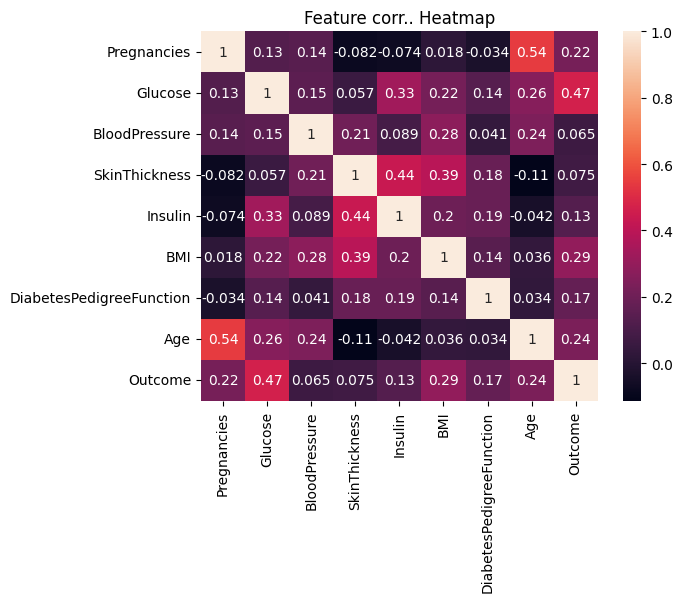

In [58]:
# Correlation heatmap
sns.heatmap(
    df.corr(),
    annot = True
)
plt.title("Feature corr.. Heatmap")

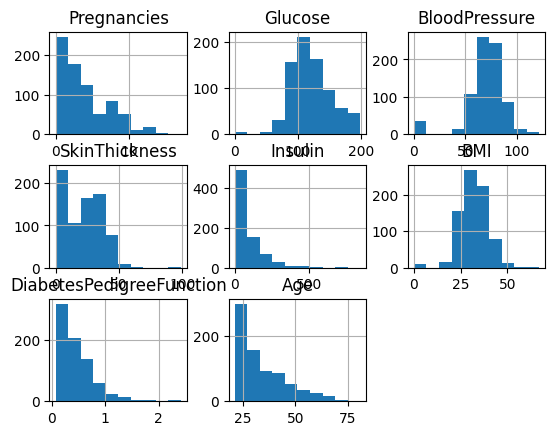

In [59]:
# feature distribution
# Remove the Outcome column
feature = df.drop("Outcome", axis = 1)
feature.hist()
plt.show()

In [60]:
# Count patinets in each outcome group
outcome_counts = df.groupby("Outcome").size()
print(outcome_counts)

Outcome
0    500
1    268
dtype: int64


## Step 4: Prepare Features and Target

> **TERM: Features (X)** — The input columns the model uses to learn  
> **TERM: Target (y)** — The output column we want to predict


In [61]:
x = df.drop("Outcome", axis = 1)
y = df['Outcome']
x.shape,y.shape

((768, 8), (768,))

## Step 5: Split Data — Train & Test Sets

> **TERM: Train Set** → Model LEARNS from this (80% of data)  
> **TERM: Test Set** → Model is EVALUATED on this (20% of data) — never seen before!  
>
> **WHY?** → To check if the model learned real patterns, not just memorized training data.  
> This is like a student studying from textbooks (train) and then taking an exam (test).


In [62]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size =0.2, random_state= 42, stratify = y # keep same class ratio in both
)
print(f"Train set size: {x_train.shape}")
print(f"Test set size: {x_test.shape}")

Train set size: (614, 8)
Test set size: (154, 8)


## Step 6: Feature Scaling (Normalization)

> **TERM: Feature Scaling** — ANN is sensitive to the SCALE of input values.  
>
> Example without scaling:  
> - Age: 20–80  
> - Insulin: 0–800  
>
> The model might over-focus on Insulin just because the numbers are bigger!  
>
> **StandardScaler** converts all values to **Mean = 0, Std = 1**  
> Formula: `z = (x - mean) / std_deviation`  
>
> ⚠️ Fit the scaler **ONLY on training data**, then apply to both.  
> (Never let test data influence the scaler — that would be data leakage!)

In [63]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(" Feature scaling complete!")


 Feature scaling complete!


## Step 7: Build the ANN Model

### 🏗️ Architecture

```
Input (8 features)
      ↓
Dense Layer — 16 neurons, ReLU activation
      ↓
Dropout (30%)
      ↓
Dense Layer — 8 neurons, ReLU activation
      ↓
Dropout (20%)
      ↓
Output — 1 neuron, Sigmoid → probability (0 to 1)
```

---

| Term | Explanation |
|------|-------------|
| **Sequential** | Layers added one after another in sequence |
| **Dense Layer** | Every neuron connects to every neuron in next layer |
| **ReLU** | `max(0, x)` — Used in hidden layers. Fast & avoids vanishing gradient |
| **Sigmoid** | `1/(1+e^-x)` — Output layer, converts to probability 0→1 |
| **Dropout** | Randomly turns off neurons during training → prevents overfitting |
| **Overfitting** | Model memorizes training data, fails on new data (like cramming, not learning) |

In [64]:
tf.random.set_seed(42)  # For reproducibility
model = Sequential([

    # HIDDEN LAYER 1 — 16 neurons, ReLU activation
    Dense(units=16, activation='relu', input_shape=(8,)),
    Dropout(0.3),

    # HIDDEN LAYER 2 — 8 neurons (funnel shape: 16 → 8 → 1)
    Dense(units=8, activation='relu'),
    Dropout(0.2),

    # OUTPUT LAYER — 1 neuron, Sigmoid gives probability (0 to 1)
    Dense(units=1, activation='sigmoid')
])

print(" Model Architecture:")
model.summary()


 Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Compile the Model

> **TERM: Compile** — Configure the model before training with 3 things:  
>
> | Setting | Choice | Why |
> |---------|--------|-----|
> | **Optimizer** | Adam | Automatically adjusts learning rate. Best default choice |
> | **Loss Function** | binary_crossentropy | Standard for YES/NO classification problems |
> | **Metrics** | accuracy | Track % correct predictions during training |
>
> **TERM: Learning Rate** — How big a step to take when updating weights.  
> Too big → overshoots. Too small → learns very slowly. Adam handles this automatically!


## Step 9: Train the Model

> **TERM: Epoch** — One complete pass through all training data  
> **TERM: Batch Size** — Process 32 samples at a time, then update weights  
> **TERM: Validation Split** — Hold out 20% of training data to monitor overfitting  
> **TERM: EarlyStopping** — Auto-stop training if model stops improving (saves time!)  
>
> `patience=10` → Stop if no improvement for 10 consecutive epochs  
> `restore_best_weights=True` → Keep the best model found during training


## Step 10: Visualize Training History

> **GOOD SIGN:** Both training loss AND validation loss decrease together  
> **OVERFITTING:** Training loss goes down, but validation loss goes UP  


### Accuracy Plot

### Loss Plot

## Step 11: Make Predictions

> `model.predict()` returns **probabilities** (e.g., 0.73)  
> We convert to binary using threshold **0.5**:  
> - probability ≥ 0.5 → **1 (Diabetes)**  
> - probability < 0.5 → **0 (No Diabetes)**


## Step 12: Evaluate the Model

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | Correct / Total | Overall % correct |
| **Precision** | TP / (TP + FP) | Of predicted diabetic, how many actually are? |
| **Recall** | TP / (TP + FN) | Of actual diabetic, how many did we catch? |
| **F1 Score** | 2 × (P × R)/(P+R) | Balance of Precision & Recall |

> ⚠️ In medical diagnosis, **Recall** matters most — missing a sick patient (False Negative) is dangerous!

**Confusion Matrix:**
```
                  Predicted NO   Predicted YES
Actual NO    →  True Negative   False Positive (Type 1 Error)
Actual YES   →  False Negative  True Positive
                (Type 2 Error)

## Step 13: Predict for a Single New Patient

> Let's simulate a real-world prediction for a new, unseen patient!
